In [1]:
# first quick look at the data from jill's test platform run

In [1]:
import pandas as pd
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
plt.rcParams['xtick.top'] = True
plt.rcParams['ytick.right'] = True
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['xtick.minor.visible'] = True
plt.rcParams['ytick.minor.visible'] = True
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = 'DejaVu Sans'
# plt.rcParams['figure.figsize'] = (3,2)
# plt.rcParams["figure.dpi"] = 300
import os

In [42]:
overDF = pd.read_csv('./output/stationTest.CSV')

noMagDF = pd.read_csv('./output/noMagTRES.CSV')

In [43]:
noMagDF

,timecode,seconds,lat,lat_dir,lon,lon_dir,sensor
0,260407_231613_000,83773.000,4159.9829,N,8739.3359,W,84
1,260407_231613_427,83773.430,4159.9829,N,8739.3359,W,69
2,260407_231613_526,83773.523,4159.9829,N,8739.3359,W,79
3,260407_231613_626,83773.625,4159.9829,N,8739.3359,W,82
4,260407_231613_726,83773.727,4159.9829,N,8739.3359,W,84
...,...,...,...,...,...,...,...
5621,260407_232543_500,84343.500,4159.9912,N,8739.4141,W,118
5622,260407_232543_600,84343.602,4159.9912,N,8739.4141,W,103
5623,260407_232543_700,84343.703,4159.9912,N,8739.4141,W,106
5624,260407_232543_800,84343.797,4159.9912,N,8739.4141,W,97


In [33]:
overDF['sensor'] = pd.to_numeric(overDF['sensor'], errors='coerce')
overDF['sensor']

overDF['seconds'] = pd.to_numeric(overDF['seconds'], errors='coerce')

In [46]:
noMagSens = np.array(noMagDF['sensor'])
noMagVolt = noMagSens * 5 / 16383
noMagSecs = np.array(noMagDF['seconds'])

In [34]:
overSens = np.array(overDF['sensor'])

overSecs = np.array(overDF['seconds'])

In [35]:
overSens = overSens[3000:-3000]
overSecs = overSecs[3000:-3000]

In [36]:
overVolt = overSens * 5 / 16383

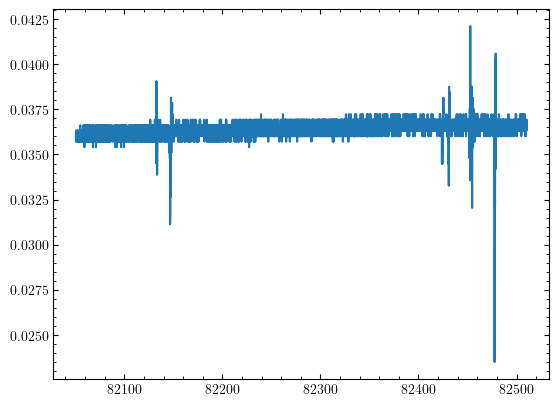

In [38]:
plt.plot(overSecs,overVolt)

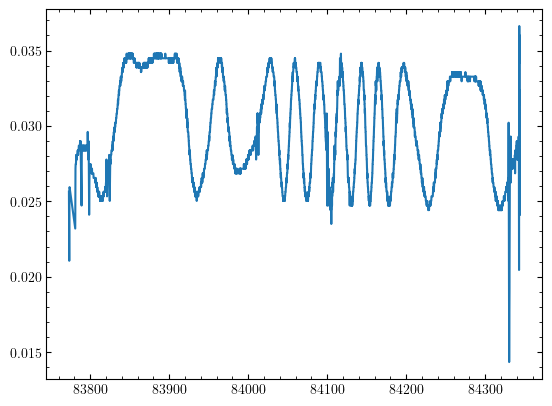

In [51]:
plt.plot(noMagSecs,noMagVolt)

In [49]:
noMagF,noMagPSD = sp.signal.welch(noMagVolt,fs=100,nperseg=300)

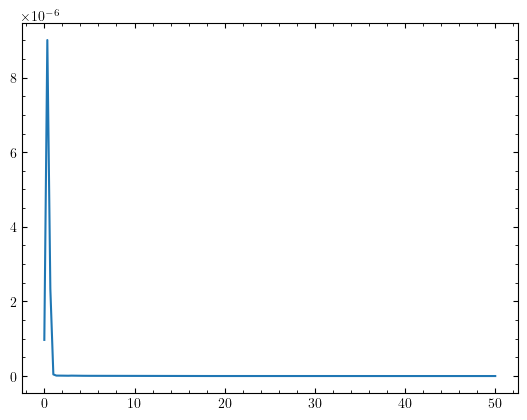

In [50]:
plt.plot(noMagF,noMagPSD)

In [39]:
overF,overPSD = sp.signal.welch(overVolt,fs=100,nperseg=300)

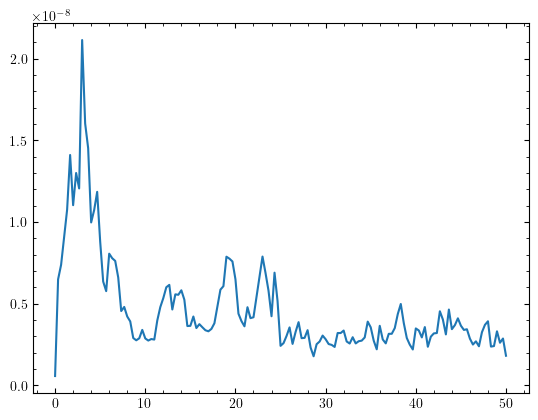

In [40]:
plt.plot(overF,overPSD)